# Homework2024 Ефремова Карина Игоревна 5030103/10301

### Постановка задачи

Необходимо решить задачу прогнозирования количества посетителей ресторанов на основе данных временного ряда.

В отчёте должны быть отражены:

1) Чтение данных и разбиение на тестовую и обучающую выборку в соотношении 3:7
2) Анализ данных с графиками
3) Выбор признаков и их кодирование
4) Анализ признаков
5) Обучение нескольких моделей и подбор гиперпараметров
6) Подсчет метрик
7) Анализ результатов


### Чтение данных

In [22]:
import pandas as pd

# Чтение данных из файлов
air_reserve = pd.read_csv("recruit-restaurant-visitor-forecasting/air_reserve.csv")
hpg_reserve = pd.read_csv("recruit-restaurant-visitor-forecasting/hpg_reserve.csv")
air_store_info = pd.read_csv("recruit-restaurant-visitor-forecasting/air_store_info.csv")
hpg_store_info = pd.read_csv("recruit-restaurant-visitor-forecasting/hpg_store_info.csv")
store_id_relation = pd.read_csv("recruit-restaurant-visitor-forecasting/store_id_relation.csv")
air_visit_data = pd.read_csv("recruit-restaurant-visitor-forecasting/air_visit_data.csv")
date_info = pd.read_csv("recruit-restaurant-visitor-forecasting/date_info.csv")
sample_submission = pd.read_csv('recruit-restaurant-visitor-forecasting/sample_submission.csv')


def print_raw_data_from_cvs():
    """
    Вывод первых 20 данных для каждой таблицы
    """
    data_dict = {
        "air_reserve": air_reserve,
        "hpg_reserve": hpg_reserve,
        "air_store_info": air_store_info,
        "hpg_store_info": hpg_store_info,
        "store_id_relation": store_id_relation,
        "air_visit_data": air_visit_data,
        "date_info": date_info,
        "sample_submission": sample_submission,
    }

    for name, df in data_dict.items():
        print(f'Таблица {name.upper()}\n')
        print(df.head(20))
        print()

print_raw_data_from_cvs()

Таблица AIR_RESERVE

            air_store_id       visit_datetime     reserve_datetime  \
0   air_877f79706adbfb06  2016-01-01 19:00:00  2016-01-01 16:00:00   
1   air_db4b38ebe7a7ceff  2016-01-01 19:00:00  2016-01-01 19:00:00   
2   air_db4b38ebe7a7ceff  2016-01-01 19:00:00  2016-01-01 19:00:00   
3   air_877f79706adbfb06  2016-01-01 20:00:00  2016-01-01 16:00:00   
4   air_db80363d35f10926  2016-01-01 20:00:00  2016-01-01 01:00:00   
5   air_db80363d35f10926  2016-01-02 01:00:00  2016-01-01 16:00:00   
6   air_db80363d35f10926  2016-01-02 01:00:00  2016-01-01 15:00:00   
7   air_3bb99a1fe0583897  2016-01-02 16:00:00  2016-01-02 14:00:00   
8   air_3bb99a1fe0583897  2016-01-02 16:00:00  2016-01-01 20:00:00   
9   air_2b8b29ddfd35018e  2016-01-02 17:00:00  2016-01-02 17:00:00   
10  air_6b15edd1b4fbb96a  2016-01-02 17:00:00  2016-01-01 22:00:00   
11  air_6b15edd1b4fbb96a  2016-01-02 17:00:00  2016-01-01 12:00:00   
12  air_6b15edd1b4fbb96a  2016-01-02 17:00:00  2016-01-02 16:00:00   

### Обработка исходных данных

In [23]:
# конвертируем в datetime тип
air_visit_data['visit_date'] = pd.to_datetime(air_visit_data['visit_date'])
date_info['calendar_date'] = pd.to_datetime(date_info['calendar_date'])

# Добавляем информацию о выходных днях
air_visit_data = air_visit_data.merge(
    date_info, left_on='visit_date', right_on='calendar_date', how='left'
)

# Удаляем повторяющиеся столбцы
air_visit_data = air_visit_data.drop(columns=['calendar_date'])

air_visit_data['month'] = air_visit_data['visit_date'].dt.month

# Добавляем оставшиюся информацию
air_visit_data = air_visit_data.merge(
    air_store_info[['air_store_id', 'air_genre_name', 'air_area_name', 'latitude', 'longitude']], on='air_store_id', how='left'
)


# Аналогично для air_reserve
air_reserve = air_reserve.drop(columns=['reserve_datetime'])
air_reserve['visit_datetime'] = pd.to_datetime(air_reserve['visit_datetime']).dt.date
air_reserve = air_reserve.groupby(['air_store_id', 'visit_datetime'], as_index=False, sort=False)['reserve_visitors'].sum()
air_reserve['visit_datetime'] = pd.to_datetime(air_reserve['visit_datetime'])


# Соединяем air_visit_data и air_reserve
air_visit_data = air_visit_data.merge(
    air_reserve[['air_store_id', 'visit_datetime', 'reserve_visitors']], left_on=['air_store_id', 'visit_date'], right_on=['air_store_id', 'visit_datetime'], how='left'
)

air_visit_data = air_visit_data.drop(columns=['visit_datetime'])

# Заполняем пустые поля Nan
air_visit_data['reserve_visitors'] = air_visit_data['reserve_visitors'].fillna(0)

# Добавляем информацию hpg
air_visit_data = air_visit_data.merge(
    store_id_relation[['air_store_id', 'hpg_store_id']], on='air_store_id', how='left'
)

# Заполняем пустые поля Nan
air_visit_data['hpg_store_id'] = air_visit_data['hpg_store_id'].fillna('unknown')

print(air_visit_data)

                air_store_id visit_date  visitors day_of_week  holiday_flg  \
0       air_ba937bf13d40fb24 2016-01-13        25   Wednesday            0   
1       air_ba937bf13d40fb24 2016-01-14        32    Thursday            0   
2       air_ba937bf13d40fb24 2016-01-15        29      Friday            0   
3       air_ba937bf13d40fb24 2016-01-16        22    Saturday            0   
4       air_ba937bf13d40fb24 2016-01-18         6      Monday            0   
...                      ...        ...       ...         ...          ...   
252103  air_24e8414b9b07decb 2017-04-18         6     Tuesday            0   
252104  air_24e8414b9b07decb 2017-04-19         6   Wednesday            0   
252105  air_24e8414b9b07decb 2017-04-20         7    Thursday            0   
252106  air_24e8414b9b07decb 2017-04-21         8      Friday            0   
252107  air_24e8414b9b07decb 2017-04-22         5    Saturday            0   

        month air_genre_name                 air_area_name   la

#### Подготовка таблицы с тестовыми данными

In [24]:
# Разделим столбец 'id' на две части: идентификатор ресторана и дату посещения
# 'id' имеет формат "<air_store_id>_<visit_date>". Разделяем по символу '_'.
sample_submission['air_store_id'] = sample_submission['id'].apply(lambda x: '_'.join(x.split('_')[:-1]))
sample_submission['visit_date'] = sample_submission['id'].apply(lambda x: x.split('_')[-1])

# Преобразуем строковый формат 'visit_date' в объект datetime для удобства работы с датами
sample_submission['visit_date'] = pd.to_datetime(sample_submission['visit_date'])

# Удаляем столбец 'id', так как больше не нужен, его данные уже разобраны
sample_submission = sample_submission.drop(columns=['id'])

# Перемещаем столбец 'visitors' в конец DataFrame для визуальной наглядности и удобства работы
sample_submission['visitors'] = sample_submission.pop('visitors')

# Объединяем с таблицей 'date_info' по дате посещения.
sample_submission = sample_submission.merge(
    date_info, left_on='visit_date', right_on='calendar_date', how='left'
)

# Удаляем столбец 'calendar_date', так как его информация уже содержится в 'visit_date'
sample_submission = sample_submission.drop(columns=['calendar_date'])

# Добавляем новый столбец 'month', чтобы иметь информацию о месяце посещения ресторана
sample_submission['month'] = sample_submission['visit_date'].dt.month

# Объединяем с таблицей 'air_store_info', чтобы добавить информацию о ресторане
sample_submission = sample_submission.merge(
    air_store_info[['air_store_id', 'air_genre_name', 'air_area_name', 'latitude', 'longitude']], on='air_store_id', how='left'
)

# Объединяем с таблицей 'air_reserve', чтобы добавить информацию о бронированиях
sample_submission = sample_submission.merge(
    air_reserve[['air_store_id', 'visit_datetime', 'reserve_visitors']], 
    left_on=['air_store_id', 'visit_date'], 
    right_on=['air_store_id', 'visit_datetime'], 
    how='left'
)

# Удаляем столбец 'visit_datetime', так как его информация уже содержится в 'visit_date'
sample_submission = sample_submission.drop(columns=['visit_datetime'])

# Для некоторых ресторанов может отсутствовать информация о количестве посетителей по бронированиям.
# Заменяем NaN на 0, так как это означает отсутствие бронирований.
sample_submission['reserve_visitors'] = sample_submission['reserve_visitors'].fillna(0)

# Объединяем с таблицей 'store_id_relation', чтобы добавить информацию о связи идентификаторов
# между air_store_id и hpg_store_id
sample_submission = sample_submission.merge(
    store_id_relation[['air_store_id', 'hpg_store_id']], on='air_store_id', how='left'
)

# Для некоторых ресторанов может отсутствовать информация о 'hpg_store_id'.
# Заменяем NaN на 'unknown', чтобы явно указать, что этой информации нет.
sample_submission['hpg_store_id'] = sample_submission['hpg_store_id'].fillna('unknown')

print(sample_submission)

               air_store_id visit_date  visitors day_of_week  holiday_flg  \
0      air_00a91d42b08b08d9 2017-04-23         0      Sunday            0   
1      air_00a91d42b08b08d9 2017-04-24         0      Monday            0   
2      air_00a91d42b08b08d9 2017-04-25         0     Tuesday            0   
3      air_00a91d42b08b08d9 2017-04-26         0   Wednesday            0   
4      air_00a91d42b08b08d9 2017-04-27         0    Thursday            0   
...                     ...        ...       ...         ...          ...   
32014  air_fff68b929994bfbd 2017-05-27         0    Saturday            0   
32015  air_fff68b929994bfbd 2017-05-28         0      Sunday            0   
32016  air_fff68b929994bfbd 2017-05-29         0      Monday            0   
32017  air_fff68b929994bfbd 2017-05-30         0     Tuesday            0   
32018  air_fff68b929994bfbd 2017-05-31         0   Wednesday            0   

       month  air_genre_name                    air_area_name   latitude  \

### Исключаем выбросы, используя правило 3х сигм

Количество глобальных выбросов (3-сигмы): 2959
Новый размер массива данных: 247103
Границы (3-сигмы) в целом: [0, 67.50814259656457]


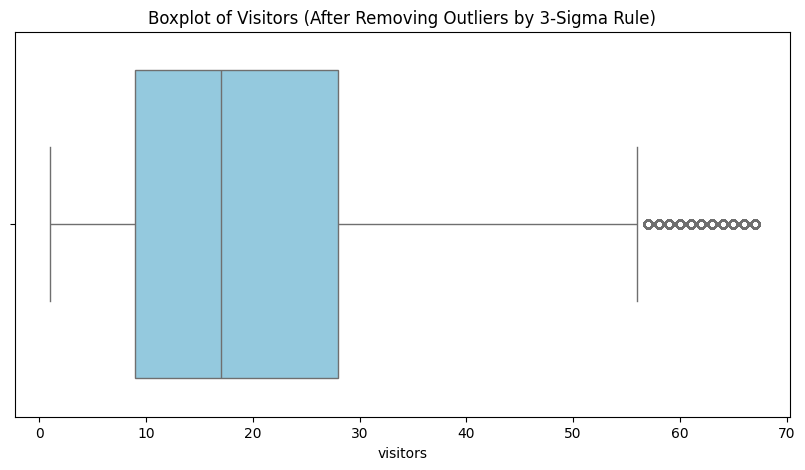

                air_store_id visit_date  visitors day_of_week  holiday_flg  \
0       air_ba937bf13d40fb24 2016-01-13        25   Wednesday            0   
1       air_ba937bf13d40fb24 2016-01-14        32    Thursday            0   
2       air_ba937bf13d40fb24 2016-01-15        29      Friday            0   
3       air_ba937bf13d40fb24 2016-01-16        22    Saturday            0   
4       air_ba937bf13d40fb24 2016-01-18         6      Monday            0   
...                      ...        ...       ...         ...          ...   
247098  air_24e8414b9b07decb 2017-04-18         6     Tuesday            0   
247099  air_24e8414b9b07decb 2017-04-19         6   Wednesday            0   
247100  air_24e8414b9b07decb 2017-04-20         7    Thursday            0   
247101  air_24e8414b9b07decb 2017-04-21         8      Friday            0   
247102  air_24e8414b9b07decb 2017-04-22         5    Saturday            0   

        month air_genre_name                 air_area_name   la

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_sigma_bounds(data, column):
    """
    Вычисляет границы на основе правила 3-х сигм.
    
    :param data: DataFrame с данными
    :param column: Название столбца для расчета границ
    :return: (нижняя граница, верхняя граница)
    """
    mean = data[column].mean()
    std = data[column].std()
    lower_bound = max(0, mean - 3 * std)  # нижняя граница (не меньше 0)
    upper_bound = mean + 3 * std  # верхняя граница
    return lower_bound, upper_bound

def filter_outliers(data, column, lower_bound, upper_bound):
    """
    Фильтрует выбросы из данных на основе переданных границ.
    
    :param data: DataFrame с данными
    :param column: Название столбца, по которому фильтруются выбросы
    :param lower_bound: Нижняя граница
    :param upper_bound: Верхняя граница
    :return: DataFrame без выбросов
    """
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Данные
cleaned_air_visit_data = pd.DataFrame()

# Исключение аномалий по каждому ресторану
for store_id, group in air_visit_data.groupby('air_store_id', as_index=False, sort=False):
    lower_bound, upper_bound = calculate_sigma_bounds(group, 'visitors')
    cleaned_group = filter_outliers(group, 'visitors', lower_bound, upper_bound)
    cleaned_air_visit_data = pd.concat([cleaned_air_visit_data, cleaned_group])

# Исключение аномалий в целом
lower_bound_global, upper_bound_global = calculate_sigma_bounds(cleaned_air_visit_data, 'visitors')

anomalies_global = cleaned_air_visit_data[
    (cleaned_air_visit_data['visitors'] < lower_bound_global) | 
    (cleaned_air_visit_data['visitors'] > upper_bound_global)
]

cleaned_air_visit_data = filter_outliers(cleaned_air_visit_data, 'visitors', lower_bound_global, upper_bound_global)

# Вывод результатов
print(f'Количество глобальных выбросов (3-сигмы): {len(anomalies_global)}')
print(f'Новый размер массива данных: {len(cleaned_air_visit_data)}')
print(f'Границы (3-сигмы) в целом: [{lower_bound_global}, {upper_bound_global}]')

# Построение графика
plt.figure(figsize=(10, 5))
sns.boxplot(x=cleaned_air_visit_data['visitors'], color='skyblue')
plt.title("Boxplot of Visitors (After Removing Outliers by 3-Sigma Rule)")
plt.show()

# Сброс индексов
cleaned_air_visit_data.reset_index(drop=True, inplace=True)
print(cleaned_air_visit_data)

### Анализ данных с графиками

#### Распределение количества посетителей за весь период

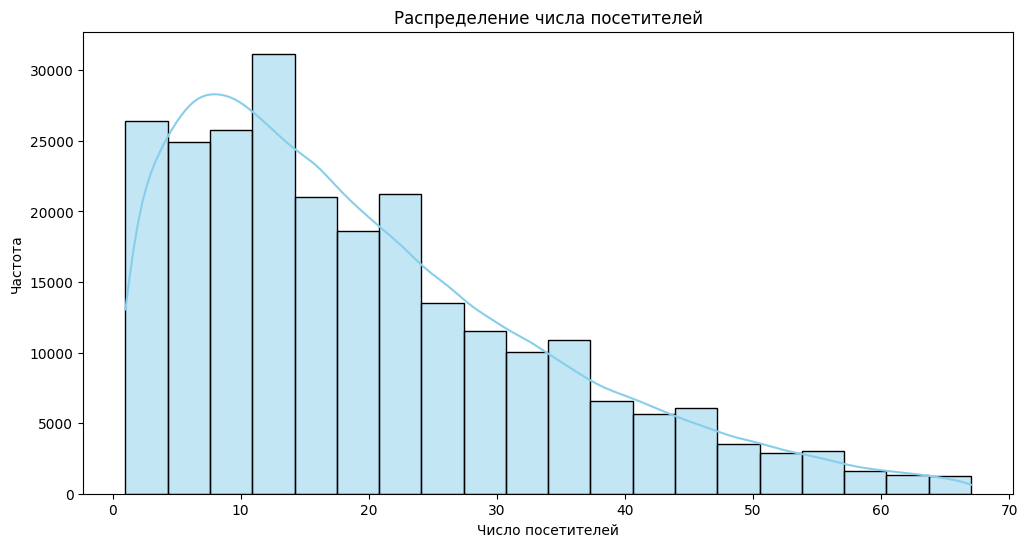

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_visitors_distribution(data, column, bins, color):
    """
    Функция для построения гистограммы распределения числа посетителей с линией KDE.
    
    :param data: DataFrame, данные для анализа.
    :param column: str, название столбца с числом посетителей.
    :param bins: int, количество интервалов (корзин) для гистограммы.
    :param color: str, цвет графика.
    """
    plt.figure(figsize=(12, 6))
    sns.histplot(data[column], bins=bins, kde=True, color=color)
    plt.title('Распределение числа посетителей')
    plt.xlabel('Число посетителей')
    plt.ylabel('Частота')
    plt.show()

plot_visitors_distribution(cleaned_air_visit_data, 'visitors', bins=20, color='skyblue')

#### Распределение среднего количества поситителей по дням недели

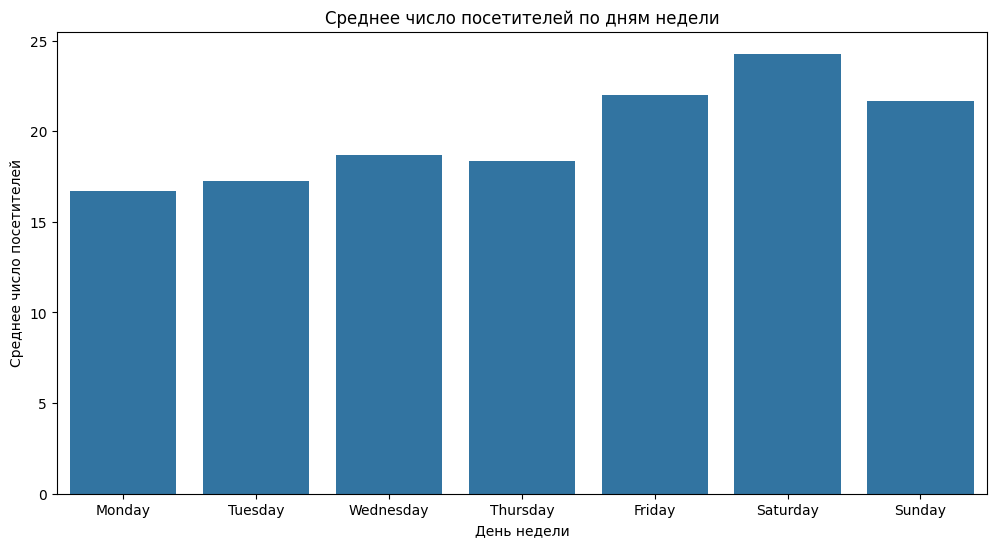

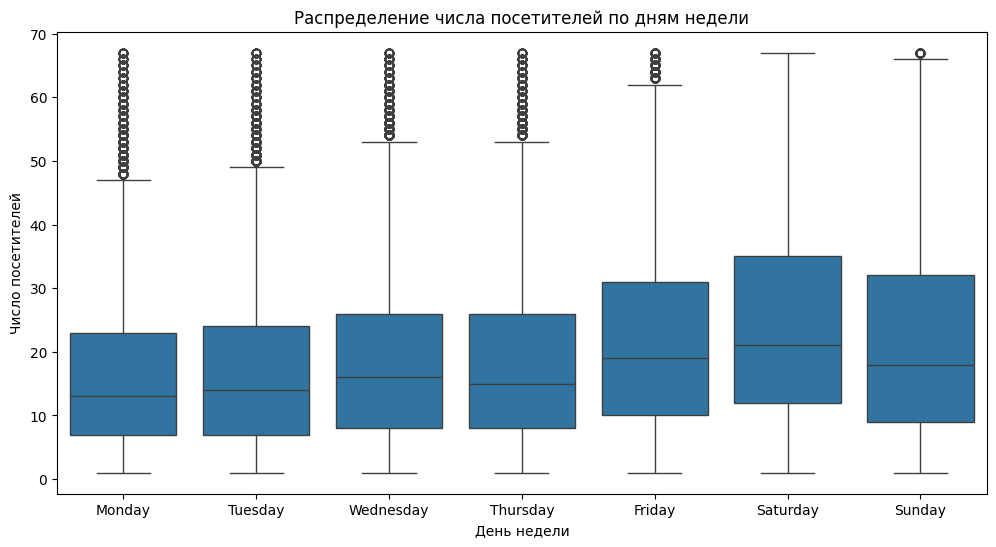

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mean_visitors_by_day(data, day_column, visitors_column, days_order):
    """
    Функция для построения столбчатой диаграммы среднего числа посетителей по дням недели.
    
    :param data: DataFrame, данные для анализа.
    :param day_column: str, название столбца с днями недели.
    :param visitors_column: str, название столбца с числом посетителей.
    :param days_order: list, порядок дней недели.
    """
    visitors_by_day = data.groupby(day_column, sort=False)[visitors_column].mean()
    plt.figure(figsize=(12, 6))
    sns.barplot(x=visitors_by_day.index, y=visitors_by_day.values, order=days_order)
    plt.title('Среднее число посетителей по дням недели')
    plt.xlabel('День недели')
    plt.ylabel('Среднее число посетителей')
    plt.show()

def plot_visitors_boxplot(data, day_column, visitors_column, days_order):
    """
    Функция для построения коробчатой диаграммы распределения числа посетителей по дням недели.
    
    :param data: DataFrame, данные для анализа.
    :param day_column: str, название столбца с днями недели.
    :param visitors_column: str, название столбца с числом посетителей.
    :param days_order: list, порядок дней недели.
    """
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=day_column, y=visitors_column, data=data, order=days_order)
    plt.title('Распределение числа посетителей по дням недели')
    plt.xlabel('День недели')
    plt.ylabel('Число посетителей')
    plt.show()

# Пример использования функций:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plot_mean_visitors_by_day(cleaned_air_visit_data, 'day_of_week', 'visitors', days_order)
plot_visitors_boxplot(cleaned_air_visit_data, 'day_of_week', 'visitors', days_order)

#### Среднее число посетителей по дням

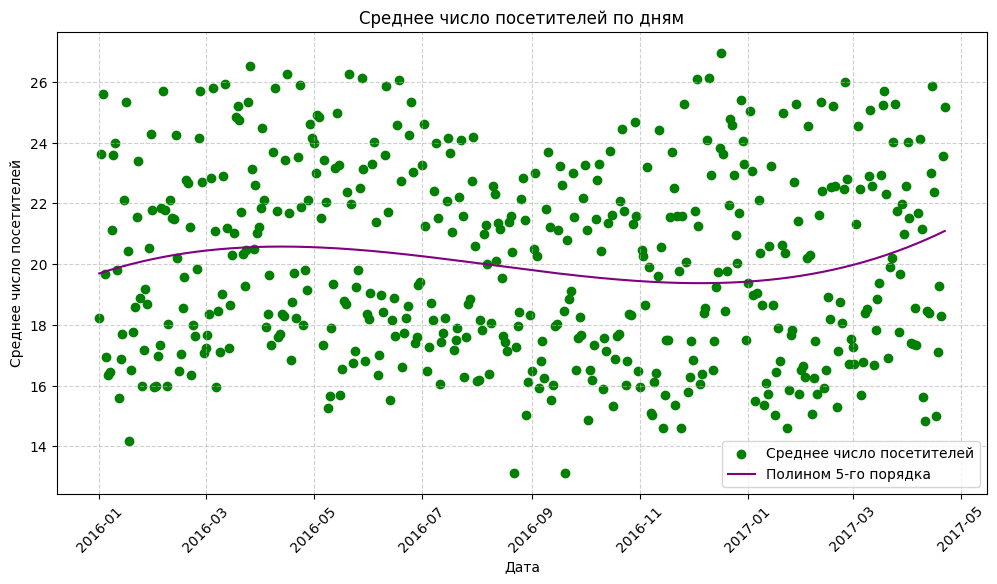

In [32]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd

# Функция для подготовки данных
def prepare_data(data):
    # Группируем данные по дате и вычисляем среднее число посетителей
    avg_visitors = data.groupby('visit_date')['visitors'].mean().reset_index()
    # Преобразуем даты в числовые значения (количество дней от минимальной даты)
    avg_X = (avg_visitors['visit_date'] - avg_visitors['visit_date'].min()).dt.days.values.reshape(-1, 1)
    avg_y = avg_visitors['visitors']
    return avg_visitors, avg_X, avg_y

# Функция для создания и обучения модели полинома
def train_polynomial_model(X, y, degree=5):
    polynom = PolynomialFeatures(degree=degree)
    polynom_X = polynom.fit_transform(X)
    model = LinearRegression()
    model.fit(polynom_X, y)
    return model, polynom_X

# Функция для построения графика
def plot_results(avg_visitors, polynom_pred_y):
    plt.figure(figsize=(12, 6))
    # Точки данных
    plt.scatter(avg_visitors['visit_date'], avg_visitors['visitors'], color='green', label='Среднее число посетителей')
    # Линия полинома
    plt.plot(avg_visitors['visit_date'], polynom_pred_y, color='purple', label='Полином 5-го порядка')

    # Настройка графика
    plt.title('Среднее число посетителей по дням')
    plt.xlabel('Дата')
    plt.ylabel('Среднее число посетителей')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Подготовка данных
avg_visitors, avg_X, avg_y = prepare_data(cleaned_air_visit_data)

# Обучение модели
model, polynom_X = train_polynomial_model(avg_X, avg_y, degree=3)
polynom_pred_y = model.predict(polynom_X)

# Построение графика
plot_results(avg_visitors, polynom_pred_y)

### Выбор признаков и их кодирование

В качестве признаков были выбраны: day_of_week, holiday_flg, month, air_genre_name, air_area_name, hpg_store_id.

Для кодирования использовался OneHotEncoder

In [34]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

def prepare_training_data(data):
    """
    Подготавливает обучающую выборку:
    1. Преобразует категориальные признаки в one-hot encoding.
    2. Удаляет ненужные столбцы.

    Args:
        data (pd.DataFrame): Исходные данные.

    Returns:
        pd.DataFrame: Преобразованная обучающая выборка.
    """
    # Создаем копию данных для работы
    data_encoded = data.copy().reset_index(drop=True)
    selected_features = data[['day_of_week', 'holiday_flg', 'month', 'air_genre_name', 'air_area_name', 'hpg_store_id']]

    # Преобразование категориальных признаков
    encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
    encoded_features = encoder.fit_transform(selected_features)

    # Создаем DataFrame из закодированных данных
    encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(selected_features.columns))

    # Объединяем исходные данные и закодированные признаки
    data_encoded = pd.concat([data_encoded, encoded_df], axis=1)

    # Удаляем ненужные столбцы
    data_encoded = data_encoded.drop(columns=['air_store_id', 'visit_date', 'visitors', 'day_of_week', 
                                              'holiday_flg', 'month', 'air_genre_name', 'air_area_name', 'hpg_store_id'])

    return data_encoded

def prepare_test_data(test_data, training_columns):
    """
    Подготавливает тестовую выборку:
    1. Преобразует категориальные признаки в one-hot encoding.
    2. Удаляет ненужные столбцы.
    3. Добавляет недостающие столбцы.

    Args:
        test_data (pd.DataFrame): Тестовые данные.
        training_columns (list): Список столбцов из обучающей выборки для приведения структур к одинаковому виду.

    Returns:
        pd.DataFrame: Преобразованная тестовая выборка.
    """
    # Создаем копию данных для работы
    test_data_encoded = test_data.copy()
    selected_features_test = test_data[['day_of_week', 'holiday_flg', 'month', 'air_genre_name', 'air_area_name', 'hpg_store_id']]

    # Преобразование категориальных признаков
    encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
    encoded_features_test = encoder.fit_transform(selected_features_test)

    # Создаем DataFrame из закодированных данных
    encoded_df_test = pd.DataFrame(encoded_features_test, columns=encoder.get_feature_names_out(selected_features_test.columns))

    # Объединяем исходные данные и закодированные признаки
    test_data_encoded = pd.concat([test_data_encoded, encoded_df_test], axis=1)

    # Удаляем ненужные столбцы
    test_data_encoded = test_data_encoded.drop(columns=['air_store_id', 'visit_date', 'visitors', 'day_of_week', 
                                                        'holiday_flg', 'month', 'air_genre_name', 'air_area_name', 'hpg_store_id'])

    # Добавляем недостающие столбцы
    missing_columns = [col for col in training_columns if col not in test_data_encoded.columns]
    for col in missing_columns:
        test_data_encoded[col] = 0.0

    # Приводим порядок столбцов к обучающей выборке
    test_data_encoded = test_data_encoded[training_columns]

    return test_data_encoded

# Подготовка обучающей выборки
cleaned_air_visit_data_encoded = prepare_training_data(cleaned_air_visit_data)

# Подготовка тестовой выборки
sample_submission_encoded = prepare_test_data(sample_submission, cleaned_air_visit_data_encoded.columns)

print(cleaned_air_visit_data_encoded)
print(sample_submission_encoded)


# import pandas as pd
# from sklearn.preprocessing import OneHotEncoder

# def prepare_training_data(data):
#     """
#     Подготовка обучающей выборки с использованием широты и долготы.
    
#     Аргументы:
#         data (pd.DataFrame): Исходный DataFrame с данными.

#     Возвращает:
#         pd.DataFrame: Закодированная обучающая выборка.
#     """
#     # Копируем данные для кодирования
#     data_encoded = data.copy().reset_index(drop=True)

#     # Выбор признаков (добавляем latitude и longitude)
#     selected_features = data[['day_of_week', 'holiday_flg', 'month', 'latitude', 'longitude']]

#     # Кодирование категориальных признаков
#     encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
#     encoded_features = encoder.fit_transform(selected_features[['day_of_week', 'holiday_flg', 'month']])

#     # Создаем DataFrame с закодированными признаками
#     encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['day_of_week', 'holiday_flg', 'month']))

#     # Объединяем закодированные данные с числовыми признаками
#     data_encoded = pd.concat([data_encoded.reset_index(drop=True), encoded_df, selected_features[['latitude', 'longitude']]], axis=1)

#     # Удаляем ненужные столбцы
#     data_encoded = data_encoded.drop(columns=['air_store_id', 'visit_date', 'visitors', 'day_of_week', 'holiday_flg', 'month'])

#     return data_encoded

# def prepare_test_data(test_data, encoder, training_columns):
#     """
#     Подготовка тестовой выборки с использованием широты и долготы.

#     Аргументы:
#         test_data (pd.DataFrame): Исходный DataFrame с тестовыми данными.
#         encoder (OneHotEncoder): Кодировщик, обученный на обучающей выборке.
#         training_columns (list): Список столбцов обучающей выборки для согласования структуры.

#     Возвращает:
#         pd.DataFrame: Закодированная тестовая выборка.
#     """
#     # Выбор признаков (добавляем latitude и longitude)
#     selected_features_test = test_data[['day_of_week', 'holiday_flg', 'month', 'latitude', 'longitude']]

#     # Кодирование категориальных признаков
#     encoded_features_test = encoder.transform(selected_features_test[['day_of_week', 'holiday_flg', 'month']])

#     # Создаем DataFrame с закодированными признаками
#     encoded_df_test = pd.DataFrame(encoded_features_test, columns=encoder.get_feature_names_out(['day_of_week', 'holiday_flg', 'month']))

#     # Объединяем закодированные данные с числовыми признаками
#     test_data_encoded = pd.concat([test_data.reset_index(drop=True), encoded_df_test, selected_features_test[['latitude', 'longitude']]], axis=1)

#     # Удаляем ненужные столбцы
#     test_data_encoded = test_data_encoded.drop(columns=['air_store_id', 'visit_date', 'visitors', 'day_of_week', 'holiday_flg', 'month'])

#     # Обеспечиваем соответствие структуры с обучающей выборкой
#     for col in training_columns:
#         if col not in test_data_encoded.columns:
#             test_data_encoded[col] = 0.0

#     return test_data_encoded[training_columns]

# # Подготовка данных
# cleaned_air_visit_data_encoded = prepare_training_data(cleaned_air_visit_data)

# # Обучаем OneHotEncoder на обучающих данных
# encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
# encoder.fit(cleaned_air_visit_data[['day_of_week', 'holiday_flg', 'month']])

# # Подготовка тестовых данных
# sample_submission_encoded = prepare_test_data(sample_submission, encoder, cleaned_air_visit_data_encoded.columns)

# print(cleaned_air_visit_data_encoded)
# print(sample_submission_encoded)

         latitude   longitude  reserve_visitors  day_of_week_Monday  \
0       35.658068  139.751599               0.0                 0.0   
1       35.658068  139.751599               0.0                 0.0   
2       35.658068  139.751599               0.0                 0.0   
3       35.658068  139.751599               0.0                 0.0   
4       35.658068  139.751599               0.0                 1.0   
...           ...         ...               ...                 ...   
247098  35.653217  139.711036               0.0                 0.0   
247099  35.653217  139.711036               0.0                 0.0   
247100  35.653217  139.711036               0.0                 0.0   
247101  35.653217  139.711036               0.0                 0.0   
247102  35.653217  139.711036               0.0                 0.0   

        day_of_week_Saturday  day_of_week_Sunday  day_of_week_Thursday  \
0                        0.0                 0.0                   0.0   

### Обучение моделей и подбор гиперпараметров

Были использованы следующие модели: K-Nearest Neighbors (KNN), Linear Regression, Lasso.

#### Краткое описание моделей

Алгоритм KNN основан на простом принципе: для нового объекта определяется его класс или значение, основываясь на ближайших K соседях в тренировочных данных.

Линейная регрессия - простая модель, которая пытается найти линейную зависимость между входными переменными и целевой переменной.

Lasso - вариант линейной регрессии, которая добавляет штраф за сумму абсолютных значений коэффициентов.

#### Метрики

Для сравнения моделей были использованы метрики MAE (средняя абсолютная ошибка) и MAPE (средний абсолютный процент ошибки).

Модель KNeighborsRegressor начала обучение
Модель KNeighborsRegressor закончила обучение
Модель KNeighborsRegressor начала предсказание
Модель KNeighborsRegressor закончила предсказание
Модель LinearRegression начала обучение
Модель LinearRegression закончила обучение
Модель LinearRegression начала предсказание
Модель LinearRegression закончила предсказание
Модель Lasso начала обучение
Модель Lasso закончила обучение
Модель Lasso начала предсказание
Модель Lasso закончила предсказание


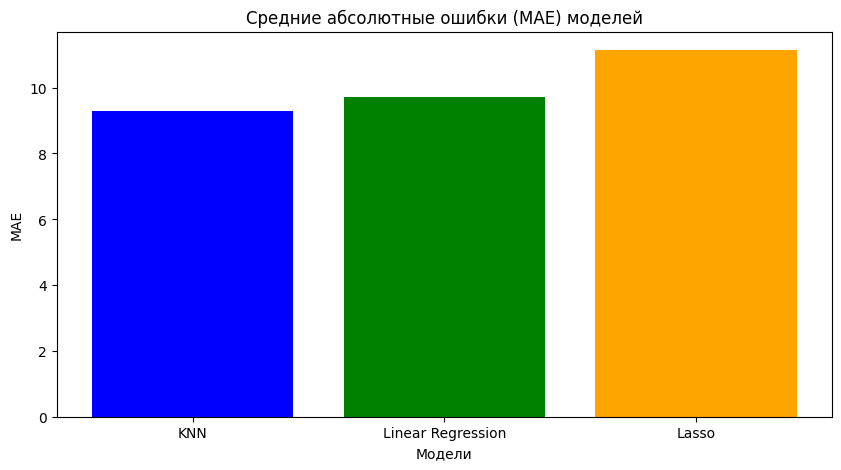

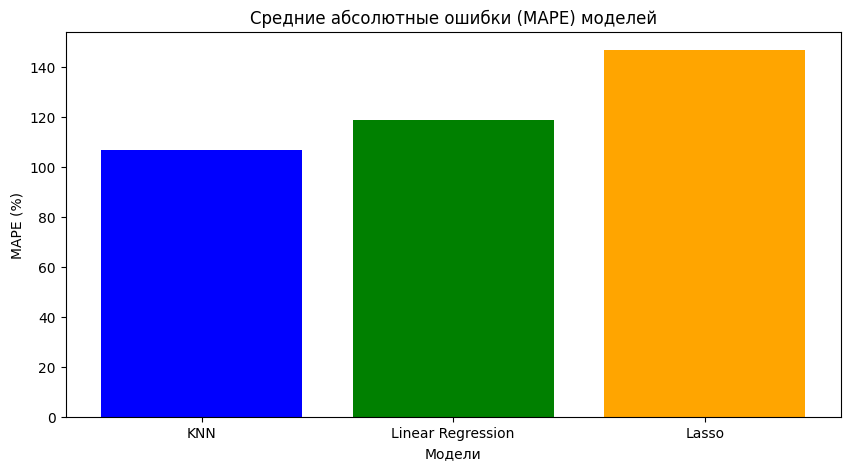

name: KNN, mae: 9.2954283633028
name: Linear Regression, mae: 9.705182130034796
name: Lasso, mae: 11.141788109891335
name: KNN, mape: 106.74869432470557
name: Linear Regression, mape: 118.9540085196831
name: Lasso, mape: 146.75226375083338


In [37]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor

# Функция для обучения модели и подсчета ошибок
def train_and_evaluate_model(model, param_grid, X_train_split, y_train_split, X_val_split, y_val_split):
    start_time = time.time()
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid)
    print(f"Модель {model.__class__.__name__} начала обучение")
    grid_search.fit(X_train_split, y_train_split)
    print(f"Модель {model.__class__.__name__} закончила обучение")
    print(f"Модель {model.__class__.__name__} начала предсказание")
    y_val_pred = grid_search.predict(X_val_split)
    print(f"Модель {model.__class__.__name__} закончила предсказание")
    end_time = time.time()

    mae = mean_absolute_error(y_val_split, y_val_pred)
    mape = mean_absolute_percentage_error(y_val_split, y_val_pred) * 100
    training_time = end_time - start_time

    return mae, mape, training_time

# Функция для построения графиков ошибок

def plot_errors(mae_scores, mape_scores):
    # График MAE
    plt.figure(figsize=(10, 5))
    plt.bar(mae_scores.keys(), mae_scores.values(), color=['blue', 'green', 'orange'])
    plt.title("Средние абсолютные ошибки (MAE) моделей")
    plt.xlabel("Модели")
    plt.ylabel("MAE")
    plt.show()

    # График MAPE
    plt.figure(figsize=(10, 5))
    plt.bar(mape_scores.keys(), mape_scores.values(), color=['blue', 'green', 'orange'])
    plt.title("Средние абсолютные ошибки (MAPE) моделей")
    plt.xlabel("Модели")
    plt.ylabel("MAPE (%)")
    plt.show()

# Данные и разделение
X_train = cleaned_air_visit_data_encoded
y_train = cleaned_air_visit_data['visitors']
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

# Модели и гиперпараметры
knn = KNeighborsRegressor()
linear_regression = LinearRegression()
lasso = Lasso()

knn_params = {'n_neighbors': [5]}
linear_regression_params = {}
lasso_params = {'alpha': [1.0]}

# Обучение и оценка моделей
mae_scores = {}
mape_scores = {}
training_times = {}

mae_scores['KNN'], mape_scores['KNN'], training_times['KNN'] = train_and_evaluate_model(
    knn, knn_params, X_train_split, y_train_split, X_val_split, y_val_split
)
mae_scores['Linear Regression'], mape_scores['Linear Regression'], training_times['Linear Regression'] = train_and_evaluate_model(
    linear_regression, linear_regression_params, X_train_split, y_train_split, X_val_split, y_val_split
)
mae_scores['Lasso'], mape_scores['Lasso'], training_times['Lasso'] = train_and_evaluate_model(
    lasso, lasso_params, X_train_split, y_train_split, X_val_split, y_val_split
)

# Построение графиков
plot_errors(mae_scores, mape_scores)

for name, score in mae_scores.items():
    print(f'name: {name}, mae: {score}')

for name, score in mape_scores.items():
    print(f'name: {name}, mape: {score}')

### Вывод

На основе данных тестов KNN показал себя лучше других моделей по метрикам MAE и MAPE. Это объясняется тем, что KNN использует локальные закономерности в данных, которые, вероятно, более выражены в данном наборе данных.

Линейная регрессия находится на втором месте, так как она работает хорошо в случае линейных зависимостей, но проигрывает KNN при наличии нелинейностей. Lasso показал худший результат, вероятно, из-за чрезмерного штрафа, который привел к потере важных признаков.